# Announced clue number across a game's arc

Plots only. The simulation lives in `scripts/tools/clue_number_arc.py` and its
results are cached, so this notebook never re-simulates:

```bash
python scripts/tools/clue_number_arc.py            # ~20 min on 16 cores, no LLM
python scripts/tools/clue_number_arc.py --reuse    # re-aggregate cached rows
```

- raw per-turn rows -> `cache/clue_number_arc_rows.json` (gitignored, regenerable)
- aggregate         -> `docs/clue_number_arc.json` (tracked)

**Why simulate rather than sample board states.** The words left late in a real
game are not a random subset of the nine: the obvious pairings went first, and
what remains is what nothing connected. Panel 2 measures that against a matched
control -- the same board, the same number of cards revealed per role, but
randomly chosen ones.

In [1]:
import json, os
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "scratch" else Path.cwd()
os.chdir(ROOT)

import numpy as np
import matplotlib.pyplot as plt

SUMMARY = ROOT / "docs" / "clue_number_arc.json"
if not SUMMARY.exists():
    raise SystemExit(
        f"No cached results at {SUMMARY}.\n"
        "This notebook only plots -- the simulation lives in a script. Run it first:\n\n"
        "    python scripts/tools/clue_number_arc.py            # ~20 min on 16 cores, no LLM\n"
        "    python scripts/tools/clue_number_arc.py --n-games 5  # quick check, ~1 min\n"
    )
S = json.loads(SUMMARY.read_text())
CFG      = S["config"]
SIGMAS   = CFG["sigmas"]
MAX_K    = CFG["max_clue_number"]
SHIPPED  = 2.5

INK, MUTED, GRID, ACCENT = "#1F2328", "#6B7280", "#E5E7EB", "#C2410C"
ramp = plt.cm.Blues(np.linspace(0.32, 0.95, len(SIGMAS)))

def arc(sg, key="arc"):
    d = S[key][str(sg)]
    ns = sorted((int(n) for n in d), reverse=True)
    return (np.array(ns),
            np.array([d[str(n)]["mean"] for n in ns]),
            np.array([d[str(n)]["se"] for n in ns]),
            np.array([d[str(n)]["count"] for n in ns]))

print(f"{CFG['n_games']} games per sigma, guesser {CFG['guesser']}, MAX_CLUE_NUMBER={MAX_K}")
print(f"{'sigma':>6} {'pooled k':>9} {'opening k':>10} {'turns':>7} {'turns/game':>11}")
for sg in SIGMAS:
    d = S["per_sigma"][str(sg)]
    print(f"{sg:>6} {d['pooled_mean']:>9.2f} {d['opening_mean']:>10.2f} {d['turns']:>7} {d['turns_per_game']:>11.1f}")

8 games per sigma, guesser noisy_numberbatch, MAX_CLUE_NUMBER=4
 sigma  pooled k  opening k   turns  turns/game
  0.25      3.16       4.00      25         3.1
   0.5      2.85       4.00      27         3.4
   1.0      2.28       3.75      32         4.0
   1.5      1.66       2.75      44         5.5
   2.0      1.29       2.25      56         7.0
   2.5      1.12       1.75      65         8.1
   3.0      1.03       1.25      71         8.9
   4.0      1.01       1.12      73         9.1
   6.0      1.00       1.00      80        10.0
  10.0      1.00       1.00     105        13.1


## The arc, one line per noise level

`sigma` is an **ordered** variable, so the lines take a single-hue sequential
ramp (light = low, dark = high) rather than categorical colours. The shipped
value is drawn in an accent with a 95% band.

Below `n = 4` the number is capped by `min(n, MAX_CLUE_NUMBER)`, so that region
is shaded: any fall there is mechanical, not a model decision. Point size
encodes how many turns back each mean -- the `n = 8` column is starved at low
sigma, because a team announcing >= 2 steps from 9 own words straight to 7.

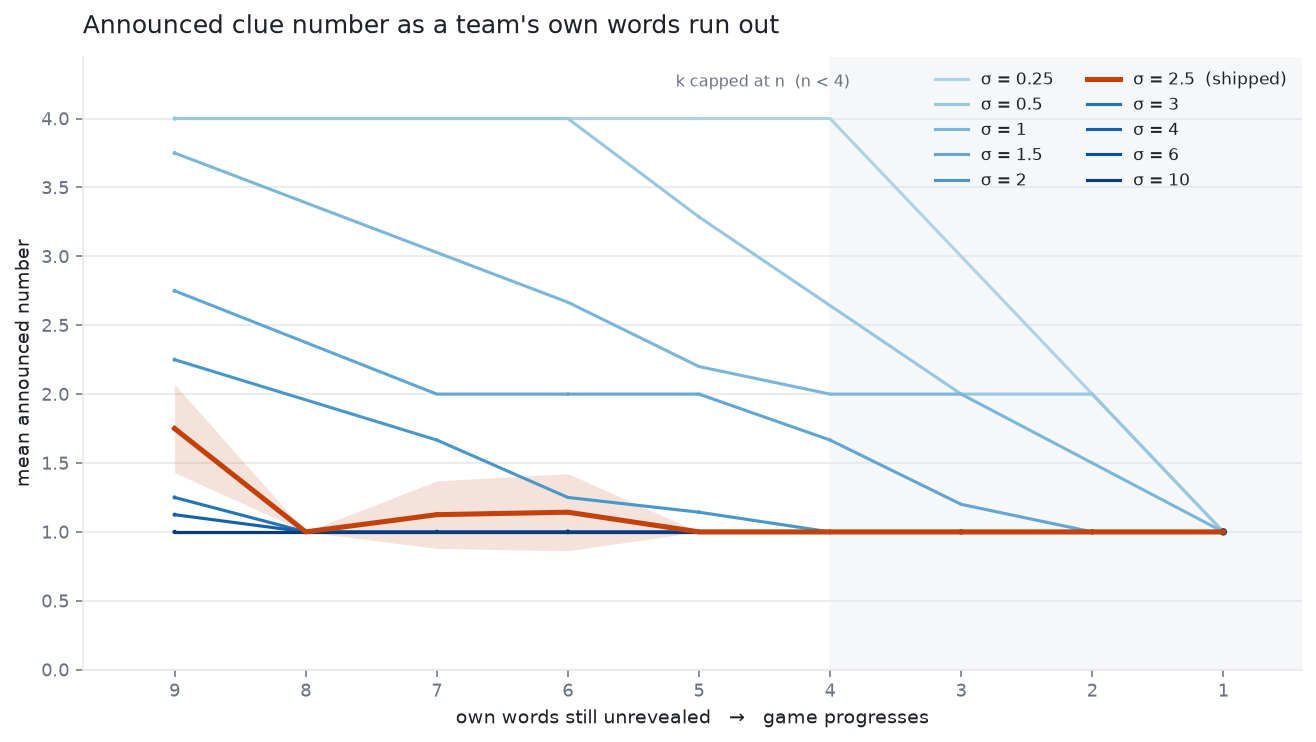

In [2]:
fig, ax = plt.subplots(figsize=(9.5, 5.4), dpi=140)
ax.axvspan(0.4, MAX_K, color="#F6F7F8", zorder=0)
ax.text(MAX_K - 0.15, 4.32, f"k capped at n  (n < {MAX_K})", ha="right", va="top",
        fontsize=8, color=MUTED)

for sg, c in zip(SIGMAS, ramp):
    ns, m, se, cnt = arc(sg)
    hit = sg == SHIPPED
    col = ACCENT if hit else c
    ax.plot(ns, m, color=col, lw=2.6 if hit else 1.6, zorder=5 if hit else 3,
            label=f"\u03c3 = {sg:g}" + ("  (shipped)" if hit else ""))
    # marker area ~ turns behind each mean; a starved point reads as a small dot
    ax.scatter(ns, m, s=np.clip(cnt, 4, 120) * (0.55 if not hit else 0.8),
               color=col, zorder=6 if hit else 4, linewidths=0)
    if hit:
        ax.fill_between(ns, m - 1.96 * se, m + 1.96 * se, color=ACCENT, alpha=0.15, lw=0, zorder=2)

ax.set_xlim(9.7, 0.4); ax.set_ylim(0, 4.45); ax.set_xticks(range(9, 0, -1))
ax.set_xlabel("own words still unrevealed   \u2192   game progresses", color=INK)
ax.set_ylabel("mean announced number", color=INK)
ax.set_title("Announced clue number as a team's own words run out", loc="left",
             fontsize=13, color=INK, pad=12)
ax.grid(axis="y", color=GRID, lw=0.8); ax.set_axisbelow(True)
for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
for s_ in ("left", "bottom"): ax.spines[s_].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="upper right", labelcolor=INK)
fig.tight_layout(); plt.show()

## Does the selection effect exist?

If the words a real game leaves behind are genuinely harder to clue, the
shuffled twin should support a **higher** announced number at the same
own-count.

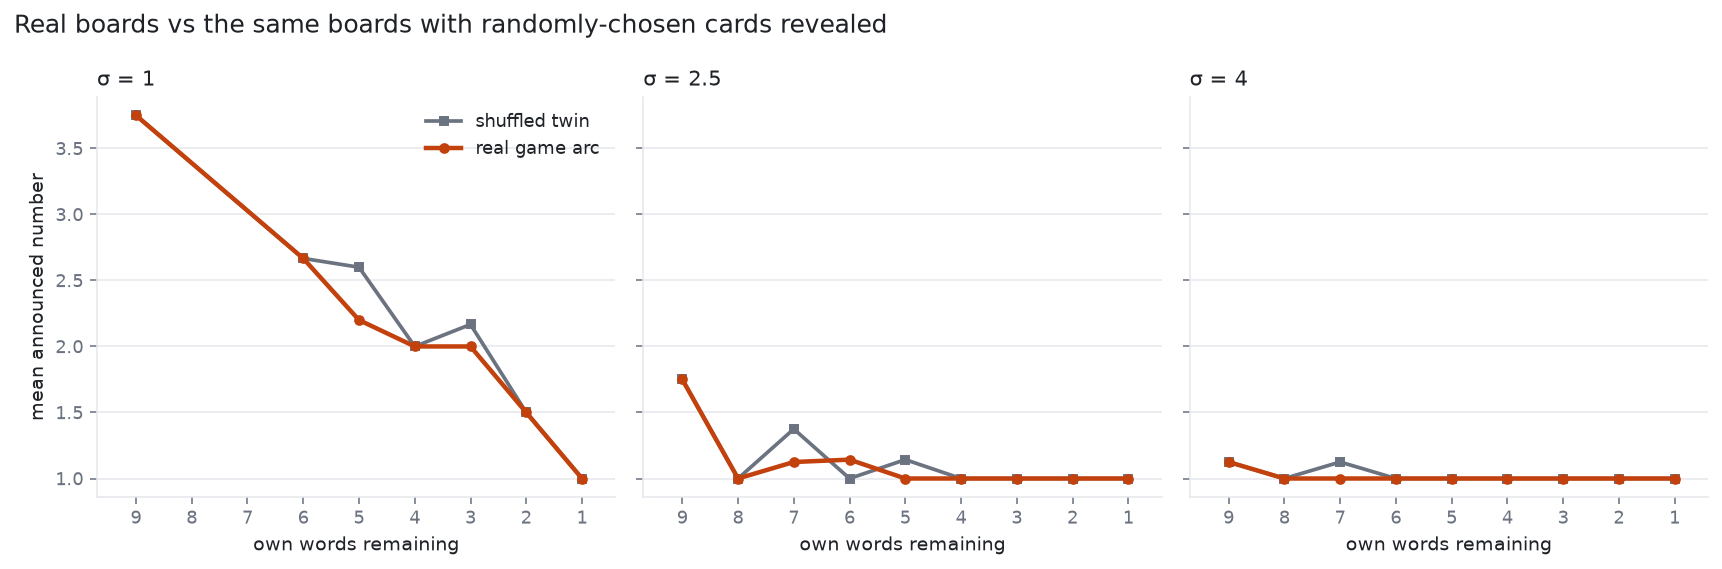

 sigma   n    real    twin  twin-real
   1.0   9    3.75    3.75      +0.00
   1.0   6    2.67    2.67      +0.00
   1.0   5    2.20    2.60      +0.40
   1.0   4    2.00    2.00      +0.00
   1.0   3    2.00    2.17      +0.17
   1.0   2    1.50    1.50      +0.00
   1.0   1    1.00    1.00      +0.00
   2.5   9    1.75    1.75      +0.00
   2.5   8    1.00    1.00      +0.00
   2.5   7    1.12    1.38      +0.25
   2.5   6    1.14    1.00      -0.14
   2.5   5    1.00    1.14      +0.14
   2.5   4    1.00    1.00      +0.00
   2.5   3    1.00    1.00      +0.00
   2.5   2    1.00    1.00      +0.00
   2.5   1    1.00    1.00      +0.00
   4.0   9    1.12    1.12      +0.00
   4.0   8    1.00    1.00      +0.00
   4.0   7    1.00    1.12      +0.12
   4.0   6    1.00    1.00      +0.00
   4.0   5    1.00    1.00      +0.00
   4.0   4    1.00    1.00      +0.00
   4.0   3    1.00    1.00      +0.00
   4.0   2    1.00    1.00      +0.00
   4.0   1    1.00    1.00      +0.00


In [3]:
TWINS = CFG["twin_sigmas"]
fig, axes = plt.subplots(1, len(TWINS), figsize=(4.1 * len(TWINS), 4.1), dpi=140, sharey=True)
axes = np.atleast_1d(axes)
for ax, sg in zip(axes, TWINS):
    ns, rm, rse, _ = arc(sg, "arc")
    tn, tm, tse, _ = arc(sg, "twin")
    tmap = dict(zip(tn, tm))
    ax.plot(ns, [tmap.get(n, np.nan) for n in ns], color=MUTED, lw=1.9, marker="s", ms=4,
            label="shuffled twin")
    ax.plot(ns, rm, color=ACCENT, lw=2.3, marker="o", ms=4.5, label="real game arc")
    ax.set_xlim(9.7, 0.4); ax.set_xticks(range(9, 0, -1))
    ax.set_title(f"\u03c3 = {sg:g}", loc="left", fontsize=11, color=INK)
    ax.grid(axis="y", color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
    for s_ in ("left", "bottom"): ax.spines[s_].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_xlabel("own words remaining", color=INK)
axes[0].set_ylabel("mean announced number", color=INK)
axes[0].legend(frameon=False, fontsize=9, labelcolor=INK)
fig.suptitle("Real boards vs the same boards with randomly-chosen cards revealed",
             x=0.004, ha="left", fontsize=13, color=INK)
fig.tight_layout(); plt.show()

print(f"{'sigma':>6} {'n':>3} {'real':>7} {'twin':>7} {'twin-real':>10}")
for sg in TWINS:
    ns, rm, _, _ = arc(sg, "arc")
    tn, tm, _, _ = arc(sg, "twin")
    tmap = dict(zip(tn, tm))
    for n, r_ in zip(ns, rm):
        if n in tmap:
            print(f"{sg:>6} {n:>3} {r_:>7.2f} {tmap[n]:>7.2f} {tmap[n] - r_:>+10.2f}")

## Notes

- **The guesser shares the spymaster's embedding space**, so it is a
  near-perfect listener (~99.9% own-word rate). Deliberate: it keeps guesser
  error out of the arc, so what moves is the board and not the listener. These
  games therefore run cleaner than real ones.
- **Coverage per `n` is uneven by construction** -- point size shows it. The
  pooled per-sigma mean is confounded for the same reason: turns per game runs
  ~3.4 at sigma=0.25 to ~13.5 at sigma=10, so pooling mixes what a sigma
  announces with which states it spends its turns in. The opening (n=9) column
  is the clean comparison: exactly one per game, same count for every sigma.